<a href="https://colab.research.google.com/github/mohanad-yasser/hotel-booking/blob/work/Another_copy_of_hotel_booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- USERS ---
📈 Plotting: join_date


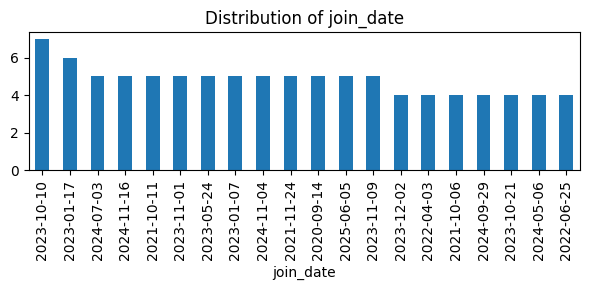


--- HOTELS ---
📈 Plotting: hotel_name


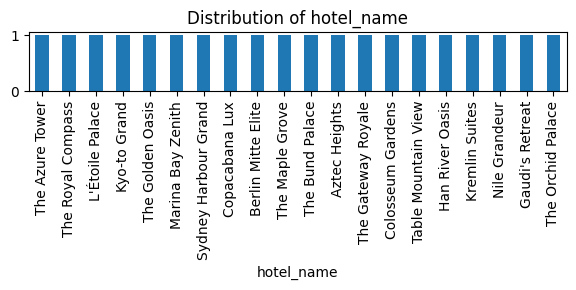

📈 Plotting: star_rating


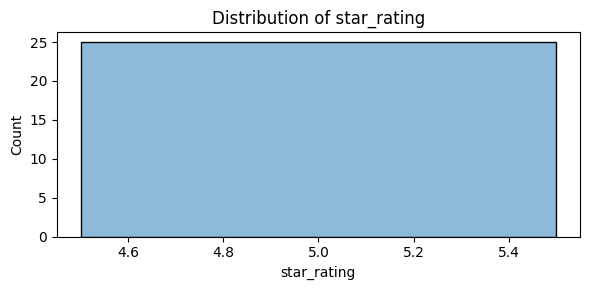

📈 Plotting: lat


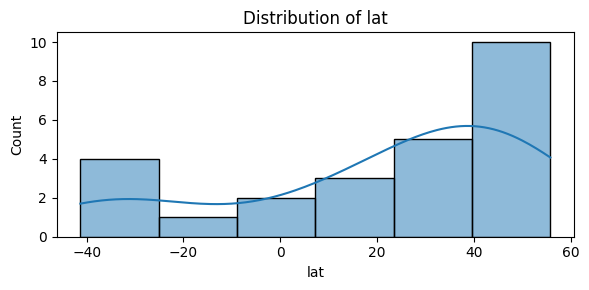

📈 Plotting: lon


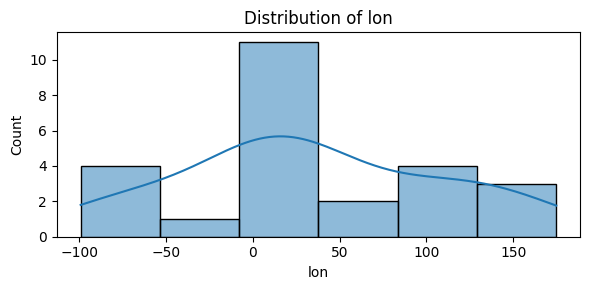


--- REVIEWS ---
📈 Plotting: review_text


/tmp/ipython-input-2771917156.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


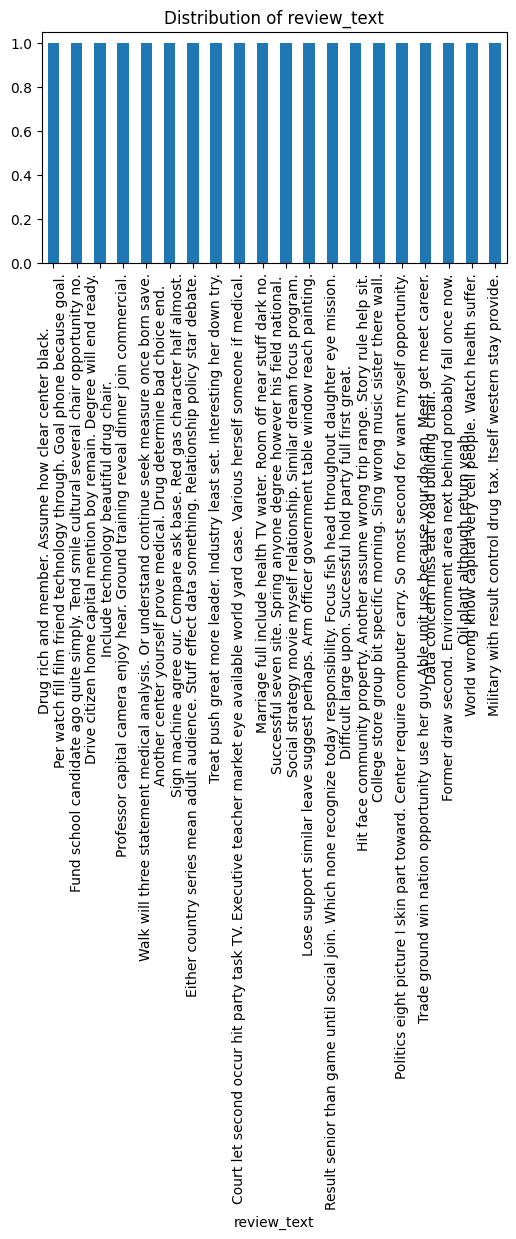

✅ Users dataframe shape after drop  : (2000, 5)
✅ Hotels dataframe shape after drop : (25, 9)
✅ Reviews dataframe shape after drop: (50000, 11)


,user_id,user_gender,country,age_group,traveller_type
0,1,Female,United Kingdom,35-44,Solo
1,2,Male,United Kingdom,25-34,Solo
2,3,Female,Mexico,25-34,Family
3,4,Male,India,35-44,Family
4,5,Other,Japan,25-34,Solo


,hotel_id,city,country,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,New York,United States,9.1,8.8,8.9,9.5,8.6,8.0
1,2,London,United Kingdom,9.0,9.2,8.8,9.4,9.0,7.9
2,3,Paris,France,8.8,9.4,8.7,9.6,9.3,8.1
3,4,Tokyo,Japan,9.6,9.0,9.3,8.5,9.5,8.2
4,5,Dubai,United Arab Emirates,9.3,9.5,9.6,8.9,9.4,8.5


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

users_df   = pd.read_csv("dataset/users.csv")
hotels_df  = pd.read_csv("dataset/hotels.csv")
reviews_df = pd.read_csv("dataset/reviews.csv")

users_drop_cols   = ["join_date"]
hotels_drop_cols  = ["hotel_name", "star_rating", "lat", "lon"]
reviews_drop_cols = ["review_text"]
print("\n--- USERS ---")
for col in users_drop_cols:
    if col in users_df.columns:
        print(f"📈 Plotting: {col}")
        plt.figure(figsize=(6, 3))
        if pd.api.types.is_numeric_dtype(users_df[col]):
            sns.histplot(users_df[col], kde=True)
        else:
            users_df[col].value_counts().head(20).plot(kind='bar')
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()


print("\n--- HOTELS ---")
for col in hotels_drop_cols:
    if col in hotels_df.columns:
        print(f"📈 Plotting: {col}")
        plt.figure(figsize=(6, 3))
        if pd.api.types.is_numeric_dtype(hotels_df[col]):
            sns.histplot(hotels_df[col], kde=True)
        else:
            hotels_df[col].value_counts().head(20).plot(kind='bar')
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()


print("\n--- REVIEWS ---")
for col in reviews_drop_cols:
    if col in reviews_df.columns:
        print(f"📈 Plotting: {col}")
        plt.figure(figsize=(6, 3))
        if pd.api.types.is_numeric_dtype(reviews_df[col]):
            sns.histplot(reviews_df[col], kde=True)
        else:
            reviews_df[col].value_counts().head(20).plot(kind='bar')
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()
users_df.drop(columns=users_drop_cols, errors='ignore', inplace=True)
hotels_df.drop(columns=hotels_drop_cols, errors='ignore', inplace=True)
reviews_df.drop(columns=reviews_drop_cols, errors='ignore', inplace=True)


print(f"✅ Users dataframe shape after drop  : {users_df.shape}")
print(f"✅ Hotels dataframe shape after drop : {hotels_df.shape}")
print(f"✅ Reviews dataframe shape after drop: {reviews_df.shape}")


display(users_df.head())
display(hotels_df.head())
display(reviews_df.head())


In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("dataset")

users   = pd.read_csv(DATA_DIR / "users.csv")
hotels  = pd.read_csv(DATA_DIR / "hotels.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")

print("Loaded -> users:", users.shape, "| hotels:", hotels.shape, "| reviews:", reviews.shape)


users = users.rename(columns={"country": "user_country"})
hotels = hotels.rename(columns={"country": "hotel_country"})

merged_df = pd.merge(reviews, users, on="user_id", how="left")


merged_df = pd.merge(merged_df, hotels, on="hotel_id", how="left")

print(f"✅ Final merged dataset shape: {merged_df.shape}")
display(merged_df.head())


print("\nMissing values per column:")
print(merged_df.isnull().sum())

merged_df.to_csv("dataset/hotel_reviews_merged.csv", index=False)
print("\n💾 Merged dataset saved to: dataset/hotel_reviews_merged.csv")


Loaded -> users: (2000, 6) | hotels: (25, 13) | reviews: (50000, 12)
✅ Final merged dataset shape: (50000, 29)


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,...,hotel_country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,...,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,...,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,...,Egypt,5,30.0444,31.2357,8.8,8.7,8.6,9.1,8.7,8.4
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,...,Spain,5,41.3851,2.1734,9.2,9.1,8.9,9.7,9.0,8.8
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,...,Russia,5,55.7558,37.6173,9.1,9.3,9.0,9.0,9.1,8.6



Missing values per column:
review_id                0
user_id                  0
hotel_id                 0
review_date              0
score_overall            0
score_cleanliness        0
score_comfort            0
score_facilities         0
score_location           0
score_staff              0
score_value_for_money    0
review_text              0
user_gender              0
user_country             0
age_group                0
traveller_type           0
join_date                0
hotel_name               0
city                     0
hotel_country            0
star_rating              0
lat                      0
lon                      0
cleanliness_base         0
comfort_base             0
facilities_base          0
location_base            0
staff_base               0
value_for_money_base     0
dtype: int64

💾 Merged dataset saved to: dataset/hotel_reviews_merged.csv


/tmp/ipython-input-424951665.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_block)


,traveller_type,city,n,mean_composite,median_composite,std,ci95,mean_delta,total_n,min_n_type,rank
47,Business,Amsterdam,460.0,8.899565,8.900000,0.120082,0.010974,-0.311232,10371,104,1
34,Couple,Dubai,706.0,9.050121,9.057143,0.115456,0.008517,-0.156067,17240,173,1
72,Family,Dubai,452.0,9.194817,9.200000,0.118566,0.010931,-0.008444,11945,120,1
82,Solo,Dubai,443.0,9.091938,9.085714,0.117770,0.010967,-0.109481,10444,105,1


,traveller_type,city,n,mean_composite,median_composite,std,ci95,mean_delta,total_n,min_n_type,rank
47,Business,Amsterdam,460.0,8.899565,8.900000,0.120082,0.010974,-0.311232,10371,104,1
38,Business,Dubai,434.0,8.892758,8.900000,0.122072,0.011485,-0.319393,10371,104,2
7,Business,Singapore,407.0,8.852018,8.842857,0.119745,0.011634,-0.296724,10371,104,3
34,Couple,Dubai,706.0,9.050121,9.057143,0.115456,0.008517,-0.156067,17240,173,1
43,Couple,Amsterdam,631.0,9.049808,9.057143,0.116647,0.009102,-0.158056,17240,173,2
15,Couple,Singapore,700.0,9.006694,9.000000,0.120598,0.008934,-0.133452,17240,173,3
72,Family,Dubai,452.0,9.194817,9.200000,0.118566,0.010931,-0.008444,11945,120,1
67,Family,Amsterdam,444.0,9.186937,9.185714,0.117887,0.010966,-0.014602,11945,120,2
17,Family,Shanghai,481.0,9.152094,9.157143,0.118217,0.010565,0.017256,11945,120,3
82,Solo,Dubai,443.0,9.091938,9.085714,0.117770,0.010967,-0.109481,10444,105,1


💾 Saved: dataset/out_best_city_per_traveller_type.csv
💾 Saved: dataset/out_top3_cities_per_traveller_type.csv
💾 Saved: dataset/out_all_city_stats.csv


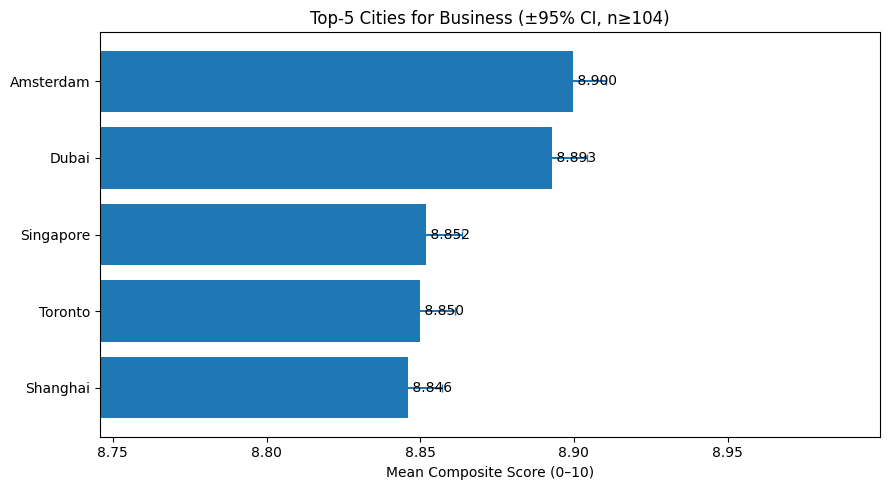

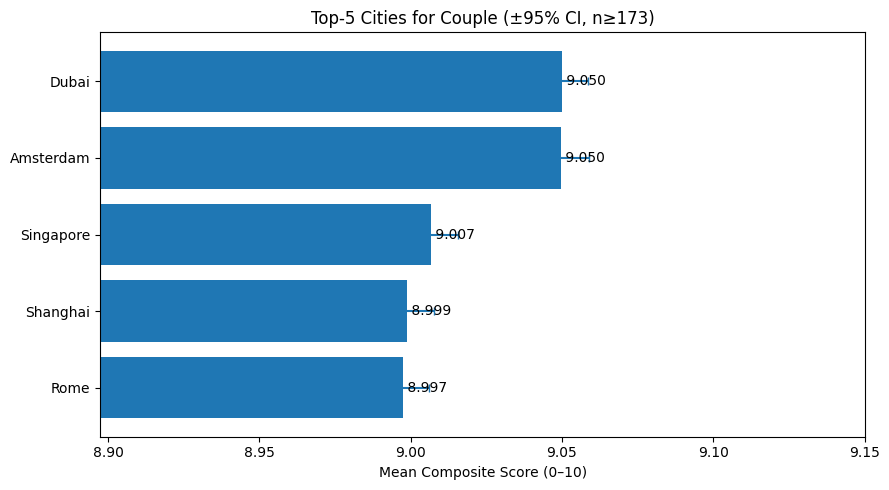

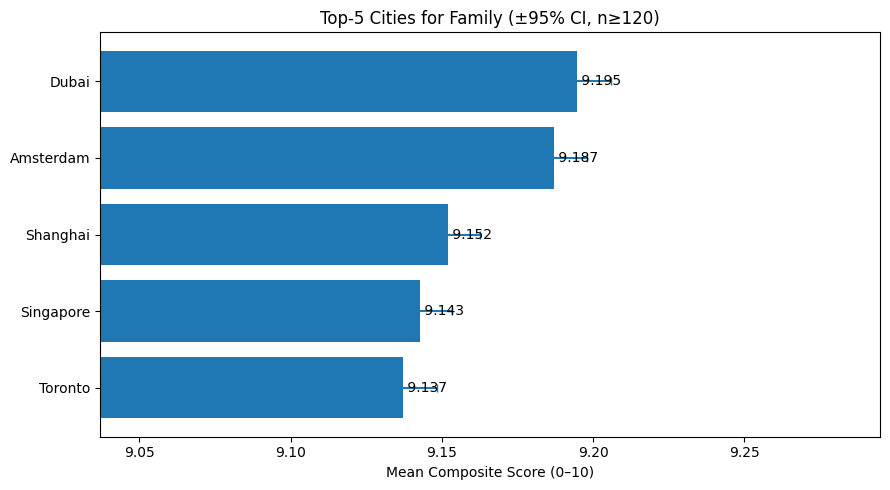

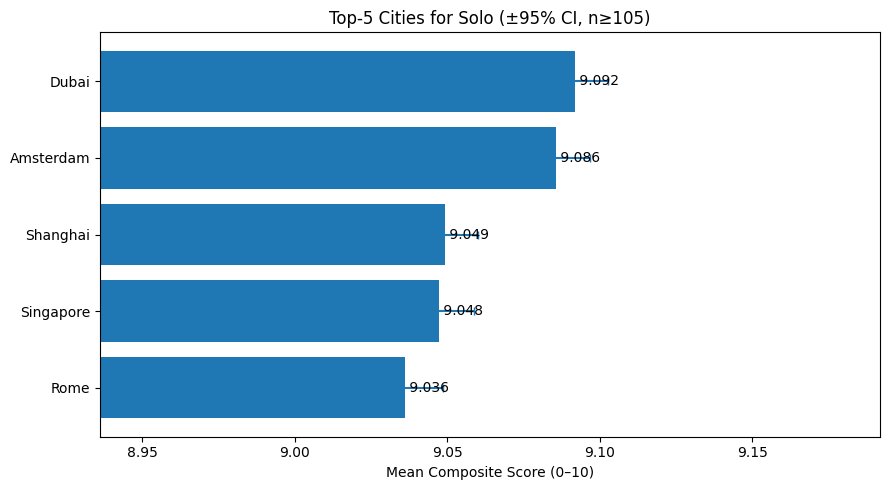

🖼️ Saved charts:
   - dataset/plot_top5_business.png
   - dataset/plot_top5_couple.png
   - dataset/plot_top5_family.png
   - dataset/plot_top5_solo.png
🖼️ Saved chart: dataset/plot_winners_summary.png


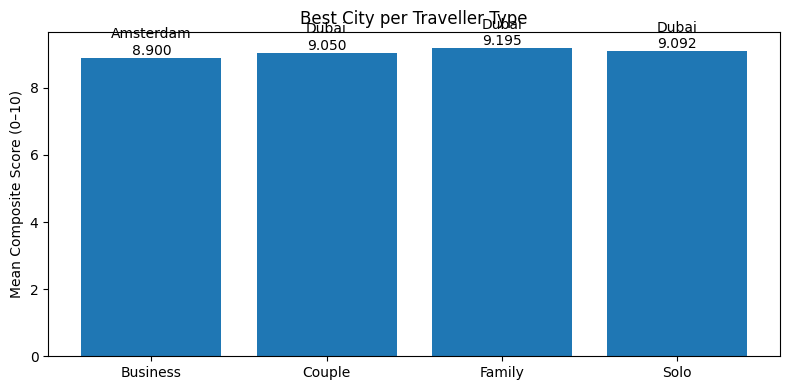

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, ceil

DATA_PATH = "dataset/hotel_reviews_merged.csv"
df = pd.read_csv(DATA_PATH)


df = df.rename(columns={"country_y": "user_country", "country_x": "hotel_country"})
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

score_cols = [
    "score_overall","score_cleanliness","score_comfort","score_facilities",
    "score_location","score_staff","score_value_for_money"
]
base_cols = [
    "cleanliness_base","comfort_base","facilities_base",
    "location_base","staff_base","value_for_money_base"
]

df = df.dropna(subset=["traveller_type","city"])

for c in score_cols:
    if c in df.columns:
        df[c] = df[c].clip(0, 10)

df["composite"] = df[score_cols].mean(axis=1)


df["delta_mean"] = (
    pd.concat([
        df["score_cleanliness"]     - df["cleanliness_base"],
        df["score_comfort"]         - df["comfort_base"],
        df["score_facilities"]      - df["facilities_base"],
        df["score_location"]        - df["location_base"],
        df["score_staff"]           - df["staff_base"],
        df["score_value_for_money"] - df["value_for_money_base"],
    ], axis=1)
    .mean(axis=1)
)

def agg_block(g: pd.DataFrame) -> pd.Series:
    n   = g.shape[0]
    m   = g["composite"].mean()
    med = g["composite"].median()
    sd  = g["composite"].std(ddof=1)
    ci  = 1.96 * (sd / sqrt(n)) if n >= 30 and pd.notna(sd) else np.nan  # normal approx
    m_delta = g["delta_mean"].mean()
    return pd.Series({
        "n": n,
        "mean_composite": m,
        "median_composite": med,
        "std": sd,
        "ci95": ci,
        "mean_delta": m_delta
    })

agg = (
    df.groupby(["traveller_type","city"], as_index=False, sort=False)
      .apply(agg_block)
      .reset_index(drop=True)
)


type_counts = df.groupby("traveller_type").size().rename("total_n")
agg = agg.merge(type_counts, on="traveller_type", how="left")
agg["min_n_type"] = (agg["total_n"] * 0.01).apply(lambda x: max(30, int(ceil(x))))
agg = agg[agg["n"] >= agg["min_n_type"]].copy()

agg = agg.sort_values(
    ["traveller_type","mean_composite","n","median_composite","city"],
    ascending=[True, False, False, False, True]
)
agg["rank"] = agg.groupby("traveller_type").cumcount() + 1

winners = agg[agg["rank"] == 1].copy()
top3    = agg[agg["rank"] <= 3].copy()

display(winners.sort_values("traveller_type"))
display(top3.sort_values(["traveller_type","rank","city"]))


winners_path = "dataset/out_best_city_per_traveller_type.csv"
top3_path    = "dataset/out_top3_cities_per_traveller_type.csv"
agg_path     = "dataset/out_all_city_stats.csv"

winners.to_csv(winners_path, index=False)
top3.to_csv(top3_path, index=False)
agg.drop(columns=["total_n","min_n_type"]).to_csv(agg_path, index=False)

print(f"💾 Saved: {winners_path}")
print(f"💾 Saved: {top3_path}")
print(f"💾 Saved: {agg_path}")


top5 = (
    agg.sort_values(["traveller_type","mean_composite","n"], ascending=[True, False, False])
       .groupby("traveller_type")
       .head(5)
)

plot_paths = []
for ttype, sub in top5.groupby("traveller_type"):
    sub = sub.sort_values("mean_composite", ascending=True)
    y = np.arange(len(sub))

    plt.figure(figsize=(9, 5))
    bars = plt.barh(y, sub["mean_composite"])

    if sub["ci95"].notna().any():
        plt.errorbar(sub["mean_composite"], y, xerr=sub["ci95"].fillna(0), fmt='none', capsize=3)


    for i, v in enumerate(sub["mean_composite"]):
        plt.text(v, i, f" {v:.3f}", va="center")


    lo = max(0, sub["mean_composite"].min() - 0.1)
    hi = min(10, sub["mean_composite"].max() + 0.1)
    plt.xlim(lo, hi)

    plt.yticks(y, sub["city"])
    plt.xlabel("Mean Composite Score (0–10)")
    min_n = int(sub["min_n_type"].iloc[0])
    plt.title(f"Top-5 Cities for {ttype} (±95% CI, n≥{min_n})")
    plt.tight_layout()

    out_png = f"dataset/plot_top5_{ttype.replace(' ','_').lower()}.png"
    plt.savefig(out_png, dpi=150)
    plot_paths.append(out_png)
    plt.show()

print("🖼️ Saved charts:")
for p in plot_paths:
    print("   -", p)


win_plot = winners.sort_values("traveller_type").copy()
plt.figure(figsize=(8, 4))
x = np.arange(win_plot.shape[0])
plt.bar(x, win_plot["mean_composite"])
for i, (city, val) in enumerate(zip(win_plot["city"], win_plot["mean_composite"])):
    plt.text(i, val, f"{city}\n{val:.3f}", ha="center", va="bottom")

plt.xticks(x, win_plot["traveller_type"], rotation=0)
plt.ylabel("Mean Composite Score (0–10)")
plt.title("Best City per Traveller Type")
plt.tight_layout()
out_png = "dataset/plot_winners_summary.png"
plt.savefig(out_png, dpi=150)
print("🖼️ Saved chart:", out_png)
plt.show()


Best city for each traveller type.
For Business Amsterdam.
For Couple Dubai.
For Family Dubai.
For Solo Dubai.


✅ Top-3 countries by Median Value-for-Money per age group:


,age_group,hotel_country,n,median_vfm
0,18-24,China,231,8.80
1,18-24,Netherlands,224,8.75
2,18-24,Canada,222,8.70
3,25-34,China,680,8.80
4,25-34,Spain,674,8.70
5,25-34,New Zealand,659,8.70
6,35-44,Netherlands,609,8.80
7,35-44,New Zealand,672,8.70
8,35-44,Canada,645,8.70
9,45-54,China,303,8.80


💾 Saved: dataset/out_top3_vfm_countries_per_agegroup.csv
💾 Saved: dataset/out_all_vfm_country_stats.csv


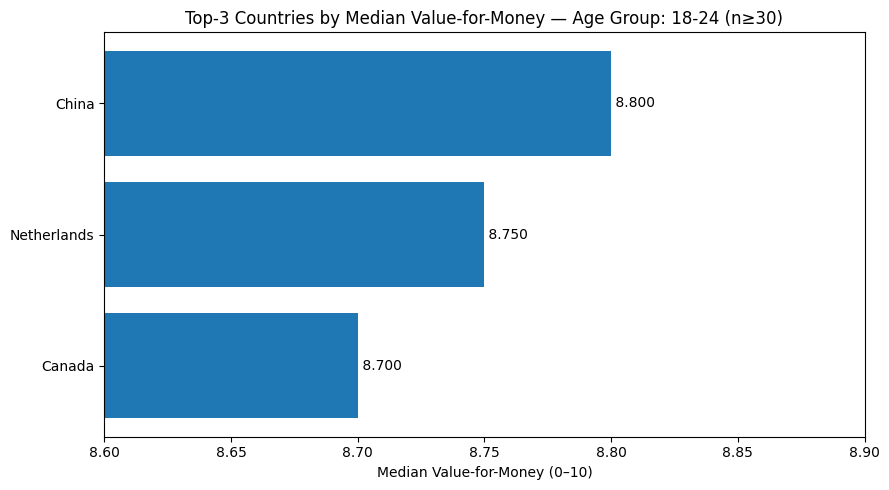

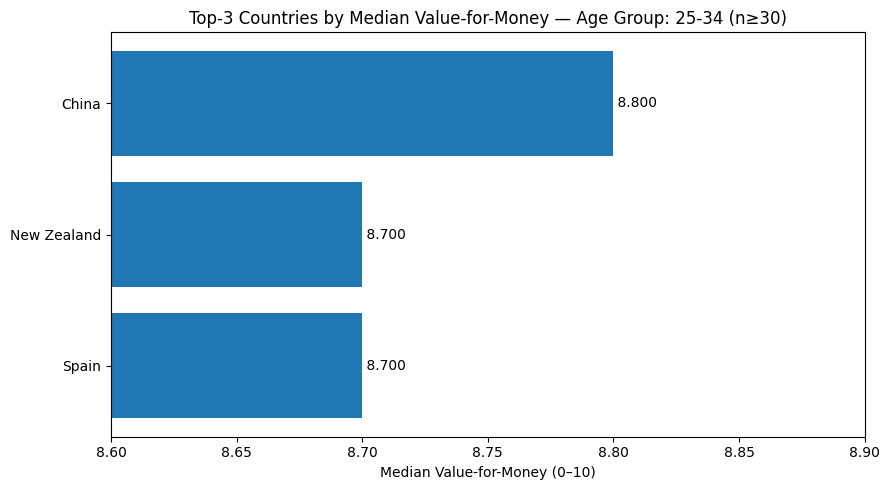

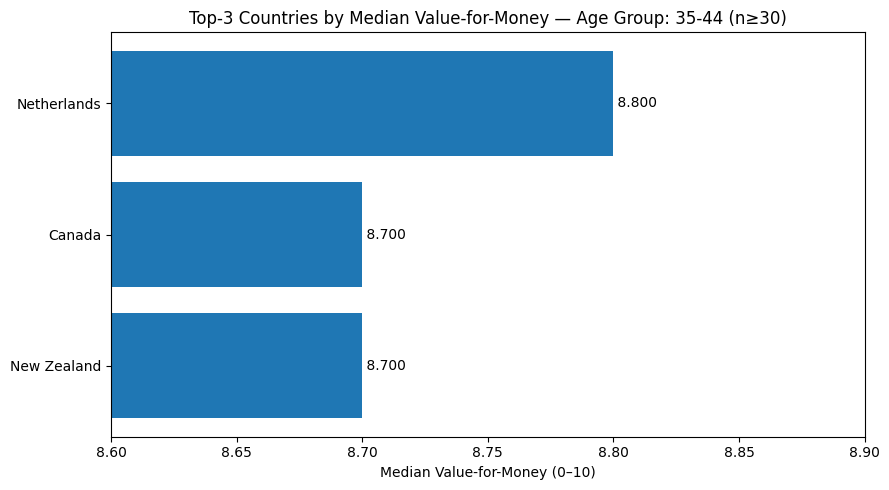

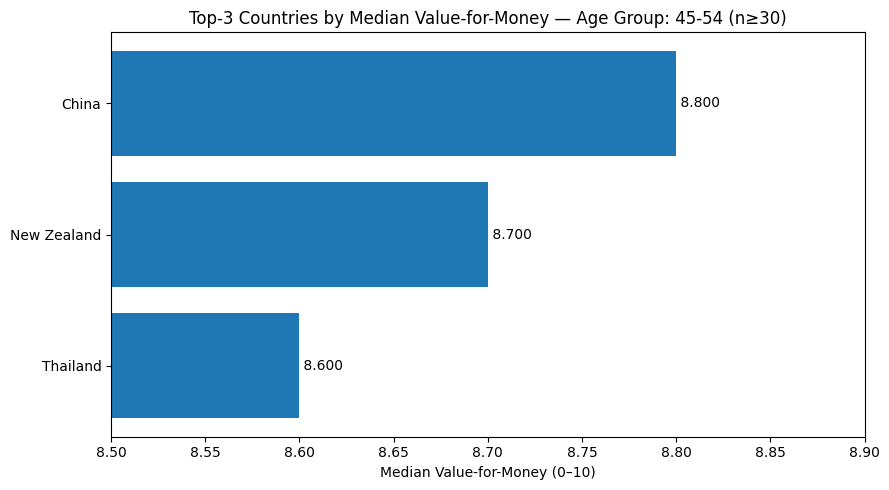

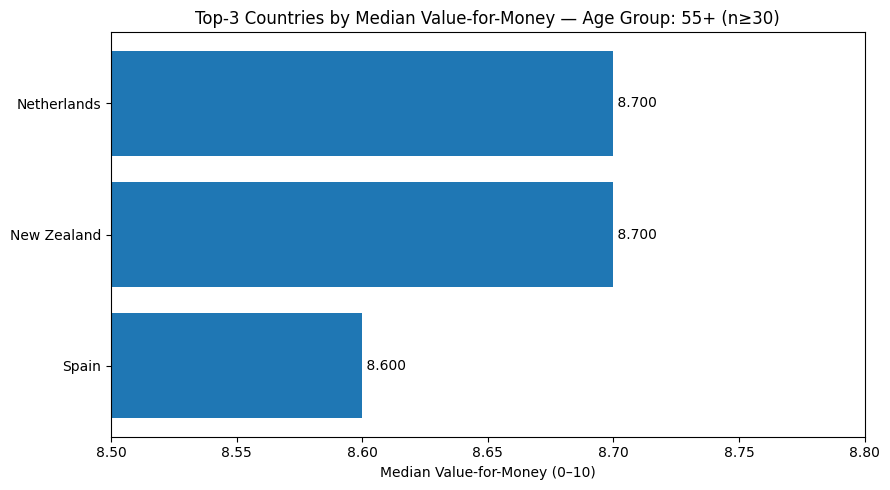

In [4]:

import pandas as pd
import numpy as np


DATA_PATH = "dataset/hotel_reviews_merged.csv"
df = pd.read_csv(DATA_PATH)


df = df.rename(columns={"country_x": "user_country", "country_y": "hotel_country"})


NEEDED = ["age_group", "hotel_country", "score_value_for_money"]
missing = [c for c in NEEDED if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df.dropna(subset=NEEDED).copy()
df["score_value_for_money"] = df["score_value_for_money"].clip(0, 10)


agg = (
    df.groupby(["age_group", "hotel_country"], as_index=False)
      .agg(
          n=("score_value_for_money", "size"),
          median_vfm=("score_value_for_money", "median"),
      )
)


MIN_N = 30
agg = agg[agg["n"] >= MIN_N].copy()


agg = agg.sort_values(
    ["age_group", "median_vfm", "n", "hotel_country"],
    ascending=[True, False, False, True]
)
agg["rank"] = agg.groupby("age_group").cumcount() + 1


top3 = (
    agg[agg["rank"] <= 3][["age_group", "hotel_country", "n", "median_vfm"]]
      .sort_values(["age_group", "median_vfm", "n", "hotel_country"],
                   ascending=[True, False, False, True])
      .reset_index(drop=True)
)

print("✅ Top-3 countries by Median Value-for-Money per age group:")
display(top3)


top3.to_csv("dataset/out_top3_vfm_countries_per_agegroup.csv", index=False)



COLS = ["age_group", "hotel_country", "n", "median_vfm"]

top3_slim = (
    top3[COLS]
    .sort_values(["age_group", "median_vfm", "n", "hotel_country"],
                 ascending=[True, False, False, True])
    .reset_index(drop=True)
)




top3_path = "dataset/out_top3_vfm_countries_per_agegroup.csv"
top3_slim.to_csv(top3_path, index=False)
print(f"💾 Saved: {top3_path}")


all_path = "dataset/out_all_vfm_country_stats.csv"
agg.to_csv(all_path, index=False)
print(f"💾 Saved: {all_path}")




for age, sub in top3_slim.groupby("age_group"):
    sub = sub.sort_values("median_vfm", ascending=True)
    y = np.arange(len(sub))

    plt.figure(figsize=(9, 5))
    plt.barh(y, sub["median_vfm"])
    plt.yticks(y, sub["hotel_country"])
    plt.xlabel("Median Value-for-Money (0–10)")
    plt.title(f"Top-3 Countries by Median Value-for-Money — Age Group: {age} (n≥{MIN_N})")

    for i, val in enumerate(sub["median_vfm"]):
        plt.text(val, i, f" {val:.3f}", va="center")

    lo = max(0, sub["median_vfm"].min() - 0.1)
    hi = min(10, sub["median_vfm"].max() + 0.1)
    plt.xlim(lo, hi)

    plt.tight_layout()
    plt.show()


Top 3 countries with the best value-for-money score per
traveler’s age group.



Age Group 18-24.
China, Netherlands and Canada.

Age Group 25-34. China, New Zealand and Spain.

Age Group 35-45. Netherlands, Canada and New Zealand.

Age Group 45-55. China, New Zealand and Thailand.

Age Group 55+. Netherlands, New Zealand and Spain.

In [5]:
df = pd.read_csv("/content/dataset/hotel_reviews_merged.csv")
country_group_mapping = {
    "United States": "North_America",
    "Canada": "North_America",
    "Germany": "Western_Europe",
    "France": "Western_Europe",
    "United Kingdom": "Western_Europe",
    "Netherlands": "Western_Europe",
    "Spain": "Western_Europe",
    "Italy": "Western_Europe",
    "Russia": "Eastern_Europe",
    "China": "East_Asia",
    "Japan": "East_Asia",
    "South Korea": "East_Asia",
    "Thailand": "Southeast_Asia",
    "Singapore": "Southeast_Asia",
    "United Arab Emirates": "Middle_East",
    "Turkey": "Middle_East",
    "Egypt": "Africa",
    "Nigeria": "Africa",
    "South Africa": "Africa",
    "Australia": "Oceania",
    "New Zealand": "Oceania",
    "Brazil": "South_America",
    "Argentina": "South_America",
    "India": "South_Asia",
    "Mexico": "North_America_Mexico"
}


df["country_group"] = df["hotel_country"].map(country_group_mapping)
df.to_csv("dataset/hotel_reviews_merged_country_groups.csv", index=False)

In [6]:
df = pd.read_csv("/content/dataset/hotel_reviews_merged_country_groups.csv")


selected_features = [
    "country_group",
    "score_overall", "score_cleanliness", "score_comfort", "score_facilities", "score_location","user_country",
    "score_staff", "score_value_for_money", "user_gender", "age_group", "traveller_type",
   "cleanliness_base", "comfort_base", "facilities_base", "location_base",
    "staff_base", "value_for_money_base"
]


existing_features = [col for col in selected_features if col in df.columns]
numerical_features = ["score_overall", "score_cleanliness", "score_comfort", "score_facilities", "score_location", "score_staff", "score_value_for_money","cleanliness_base", "comfort_base", "facilities_base", "location_base",
    "staff_base", "value_for_money_base"]
categorical_features = ["user_gender", "age_group", "traveller_type"]

filtered_df = df[existing_features]


output_path = "dataset/predict_country_groups.csv"
filtered_df.to_csv(output_path, index=False)

print(f"✅ File saved successfully at: {output_path}")
print("Included columns:", existing_features)

✅ File saved successfully at: dataset/predict_country_groups.csv
Included columns: ['country_group', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'user_country', 'score_staff', 'score_value_for_money', 'user_gender', 'age_group', 'traveller_type', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base']


In [7]:
import pandas as pd


df = pd.read_csv("dataset/predict_country_groups.csv")


categorical_features = ["age_group", "traveller_type","user_country"]


df['user_gender'] = df['user_gender'].map({'Male': 0, 'Female': 1})

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)



df_encoded.to_csv("dataset/predict_country_groups_encoded.csv", index=False)

print("✅ One-hot encoding complete. Saved as predict_country_groups_encoded.csv")


✅ One-hot encoding complete. Saved as predict_country_groups_encoded.csv


Leakage


Index(['score_overall', 'score_cleanliness', 'score_comfort',
       'score_facilities', 'score_location', 'score_staff',
       'score_value_for_money', 'user_gender', 'location_base',
       'age_group_25-34', 'age_group_35-44', 'age_group_45-54',
       'age_group_55+', 'traveller_type_Couple', 'traveller_type_Family',
       'traveller_type_Solo', 'user_country_Australia', 'user_country_Brazil',
       'user_country_Canada', 'user_country_China', 'user_country_Egypt',
       'user_country_France', 'user_country_Germany', 'user_country_India',
       'user_country_Italy', 'user_country_Japan', 'user_country_Mexico',
       'user_country_Netherlands', 'user_country_New Zealand',
       'user_country_Nigeria', 'user_country_Russia', 'user_country_Singapore',
       'user_country_South Africa', 'user_country_South Korea',
       'user_country_Spain', 'user_country_Thailand', 'user_country_Turkey',
       'user_country_United Arab Emirates', 'user_country_United Kingdom',
       'user_c

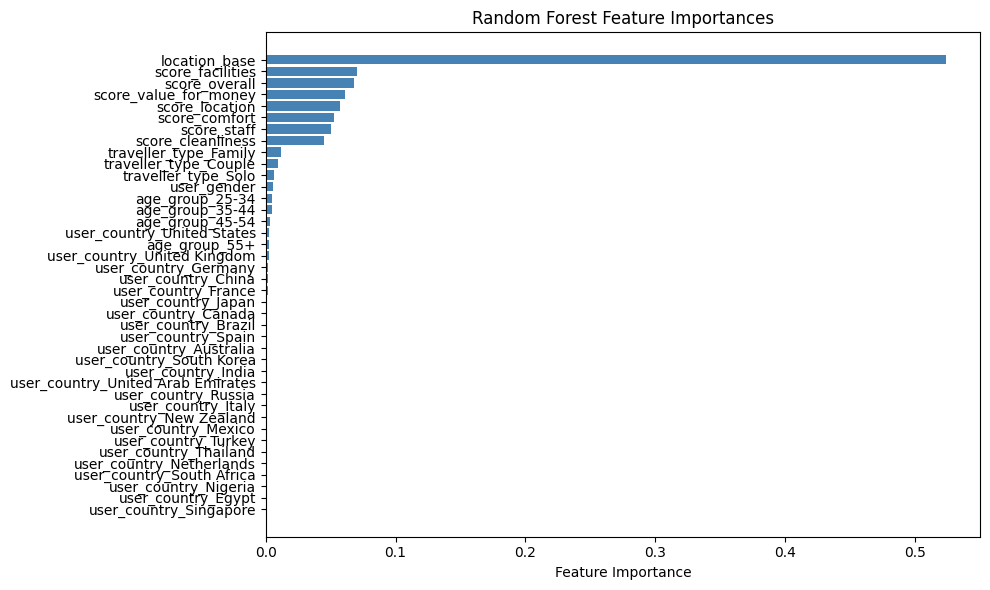

🎯 Training Accuracy: 0.7960
✅ Accuracy: 0.7059

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      1226
           1       0.80      0.64      0.71      1216
           2       0.54      0.45      0.49       394
           3       0.82      0.54      0.65       797
           4       0.88      0.82      0.85       792
           5       0.63      0.59      0.61       401
           6       0.70      0.62      0.66       803
           7       0.58      0.55      0.57       784
           8       0.99      0.71      0.82       398
           9       0.95      0.35      0.51       814
          10       0.61      0.95      0.74      2375

    accuracy                           0.71     10000
   macro avg       0.75      0.64      0.68     10000
weighted avg       0.74      0.71      0.70     10000



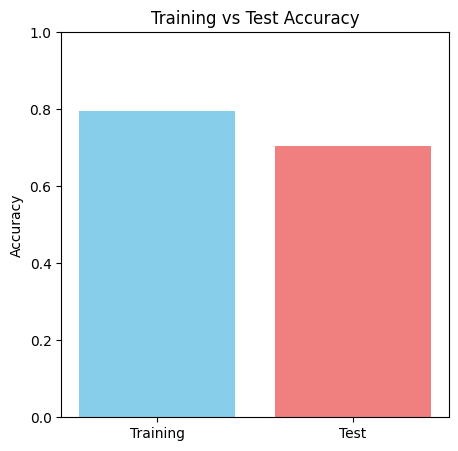

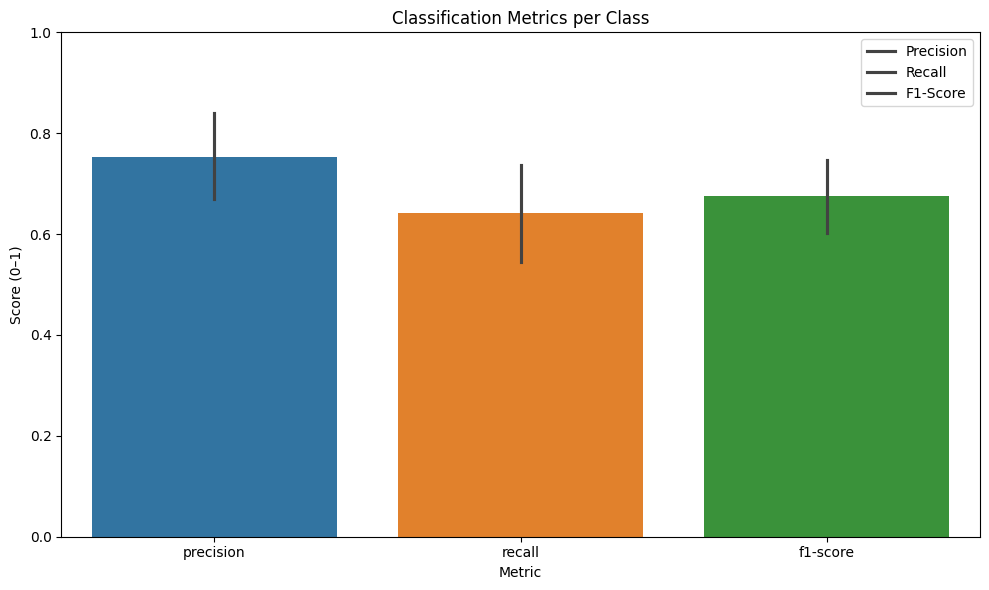


🧩 Confusion Matrix:
[[1026   15    0    0   32    0    0   41    1    1  110]
 [  26  775    0   94    0    0    0    0    0    0  321]
 [   5    0  176    0    0   29  114   62    0    0    8]
 [   7  164    0  434    0    0    0    4    3    1  184]
 [  60    7    0    0  648    0    0   53    0    0   24]
 [  24    0   25    0    0  238   19   94    0    0    1]
 [   0    0   92    0    0   10  496   55    0    0  150]
 [ 116    0   30    0   54   98   43  434    0    0    9]
 [   3    0    0    3    0    0    0    1  281    0  110]
 [   2    0    0    0    0    0    0    0    0  286  526]
 [  55    9    0    0    0    0   33    1    0   12 2265]]


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("dataset/predict_country_groups_encoded.csv")


df = df.dropna(subset=["country_group"])


X = df.drop(columns=["country_group"], errors='ignore')
leakage_cols = [col for col in X.columns if "cleanliness_base" in col.lower() or "comfort_base" in col.lower() or "staff_base" in col.lower() or "facilities_base" in col.lower() or "value_for_money_base" in col.lower()]
X = X.drop(columns=leakage_cols)
print(X.columns)
y = df["country_group"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)





from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)


importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()


class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()
print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


No leakage using one base


                              feature  importance
8                       location_base    0.222921
4                      score_location    0.183692
0                       score_overall    0.107377
3                    score_facilities    0.094003
6               score_value_for_money    0.080608
2                       score_comfort    0.074140
5                         score_staff    0.070439
1                   score_cleanliness    0.062100
14              traveller_type_Family    0.015812
13              traveller_type_Couple    0.013498
7                         user_gender    0.009721
15                traveller_type_Solo    0.008556
9                     age_group_25-34    0.007726
10                    age_group_35-44    0.007578
11                    age_group_45-54    0.004889
39         user_country_United States    0.004203
12                      age_group_55+    0.003470
38        user_country_United Kingdom    0.003459
22               user_country_Germany    0.002780


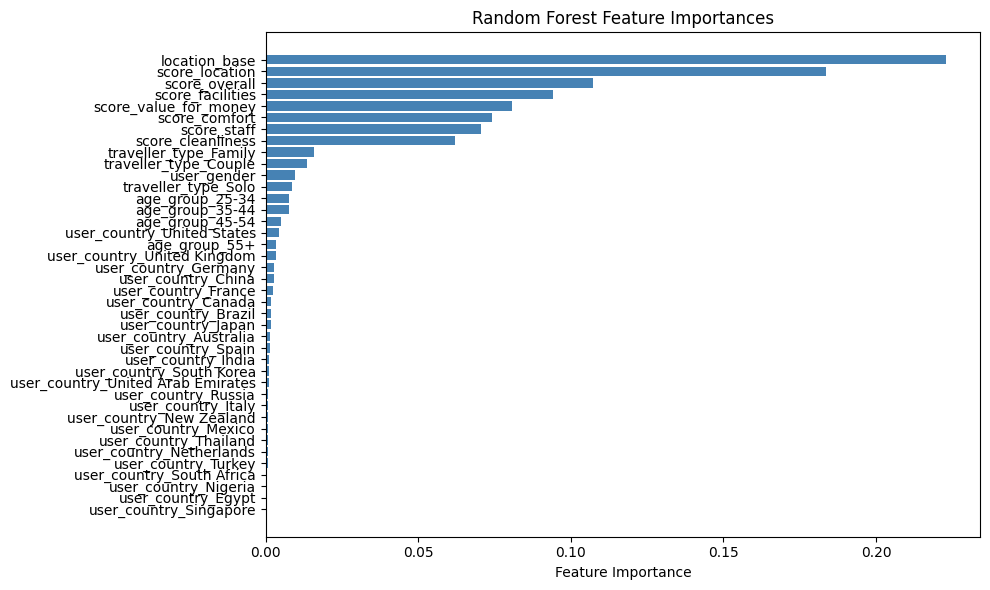

🎯 Training Accuracy: 0.5756
✅ Accuracy: 0.4788

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.60      0.49      1226
           1       0.57      0.57      0.57      1216
           2       0.44      0.04      0.07       394
           3       0.63      0.29      0.40       797
           4       0.88      0.39      0.54       792
           5       0.79      0.07      0.12       401
           6       0.73      0.18      0.29       803
           7       0.50      0.23      0.32       784
           8       0.86      0.06      0.12       398
           9       0.76      0.21      0.33       814
          10       0.42      0.95      0.58      2375

    accuracy                           0.48     10000
   macro avg       0.64      0.33      0.35     10000
weighted avg       0.58      0.48      0.43     10000



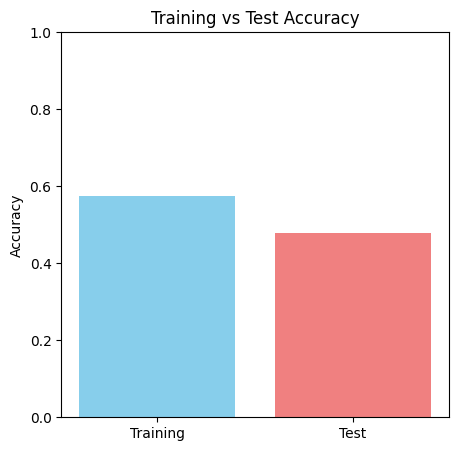

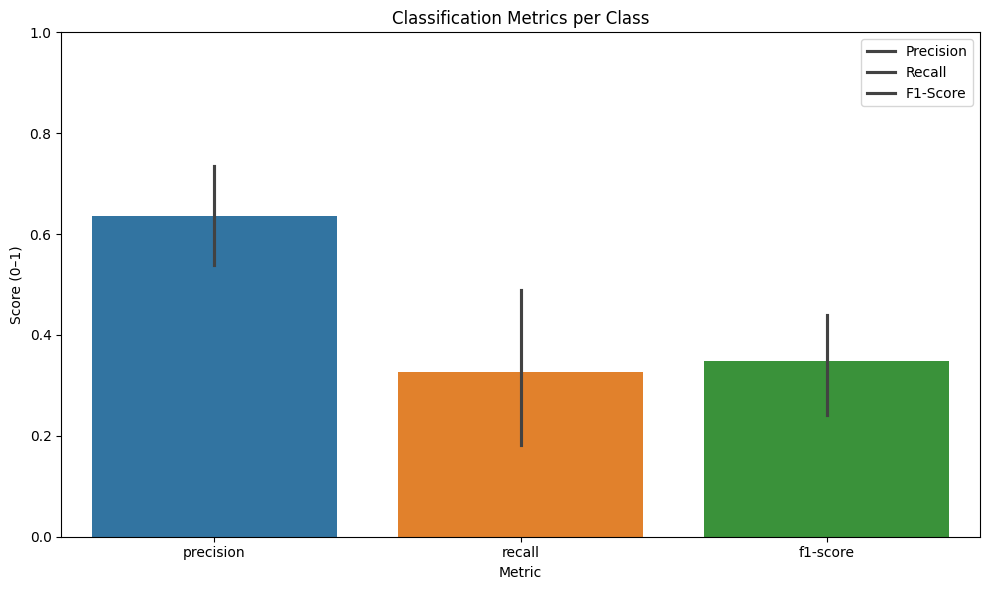


🧩 Confusion Matrix:
[[ 731   11    0    1    1    0    0   25    0    0  457]
 [  48  692    0   68    6    0    1    7    0   43  351]
 [  70   74   16   13    1    1   29   16    0    2  172]
 [  66  180    2  231    4    0    0   15    4    0  295]
 [  37  161    1   28  309    0    1   25    0    0  230]
 [ 280    0    2    1    0   27   10   31    0    0   50]
 [  43   65    9   15    7    1  148   16    0    0  499]
 [ 244    5    5    1   13    4    8  181    0    0  323]
 [ 165    2    0    0    5    1    0   40   25    0  160]
 [  14    3    0    0    0    0    0    1    0  170  626]
 [  64   19    1    6    4    0    7    6    0   10 2258]]


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("dataset/predict_country_groups_encoded.csv")


df = df.dropna(subset=["country_group"])


X = df.drop(columns=["country_group"], errors='ignore')
leakage_cols = [col for col in X.columns if "cleanliness_base" in col.lower() or "comfort_base" in col.lower() or "staff_base" in col.lower() or "facilities_base" in col.lower() or "value_for_money_base" in col.lower()]
X = X.drop(columns=leakage_cols)

X["location_base"] = X["score_location"] / (X["location_base"] + 1e-6)

y = df["country_group"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)



from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)


importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()
print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


No leakage using 2 bases


                              feature  importance
9                       location_base    0.186447
4                      score_location    0.155186
8                        comfort_base    0.146880
2                       score_comfort    0.104301
0                       score_overall    0.090051
3                    score_facilities    0.073830
6               score_value_for_money    0.063649
5                         score_staff    0.051712
1                   score_cleanliness    0.048614
15              traveller_type_Family    0.012544
14              traveller_type_Couple    0.010514
7                         user_gender    0.007265
16                traveller_type_Solo    0.006804
10                    age_group_25-34    0.006076
11                    age_group_35-44    0.005781
12                    age_group_45-54    0.003606
40         user_country_United States    0.003110
39        user_country_United Kingdom    0.002598
13                      age_group_55+    0.002544


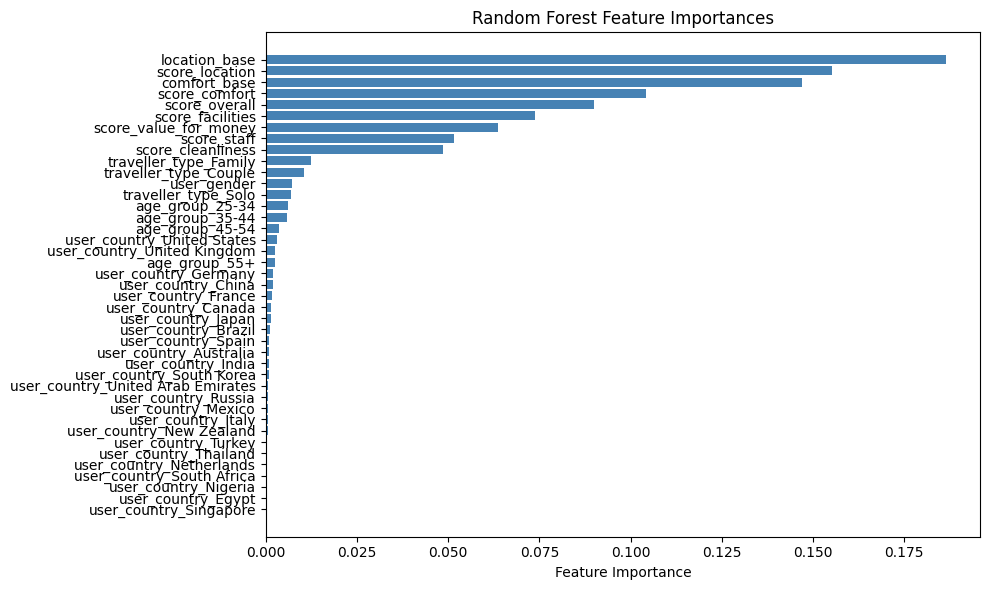

🎯 Training Accuracy: 0.6792
✅ Accuracy: 0.5666

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60      1226
           1       0.65      0.63      0.64      1216
           2       0.80      0.08      0.15       394
           3       0.76      0.40      0.52       797
           4       0.93      0.53      0.67       792
           5       0.88      0.35      0.51       401
           6       0.82      0.25      0.38       803
           7       0.62      0.56      0.59       784
           8       0.98      0.16      0.27       398
           9       0.82      0.19      0.31       814
          10       0.45      0.99      0.62      2375

    accuracy                           0.57     10000
   macro avg       0.75      0.43      0.48     10000
weighted avg       0.68      0.57      0.53     10000



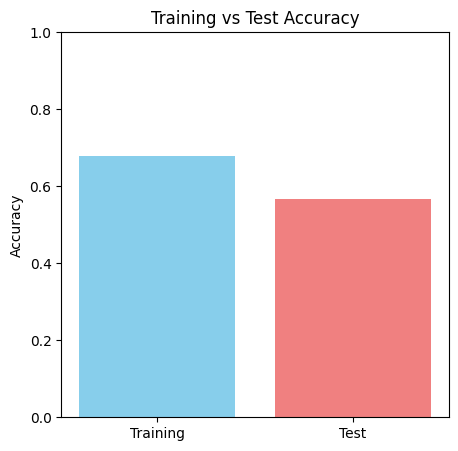

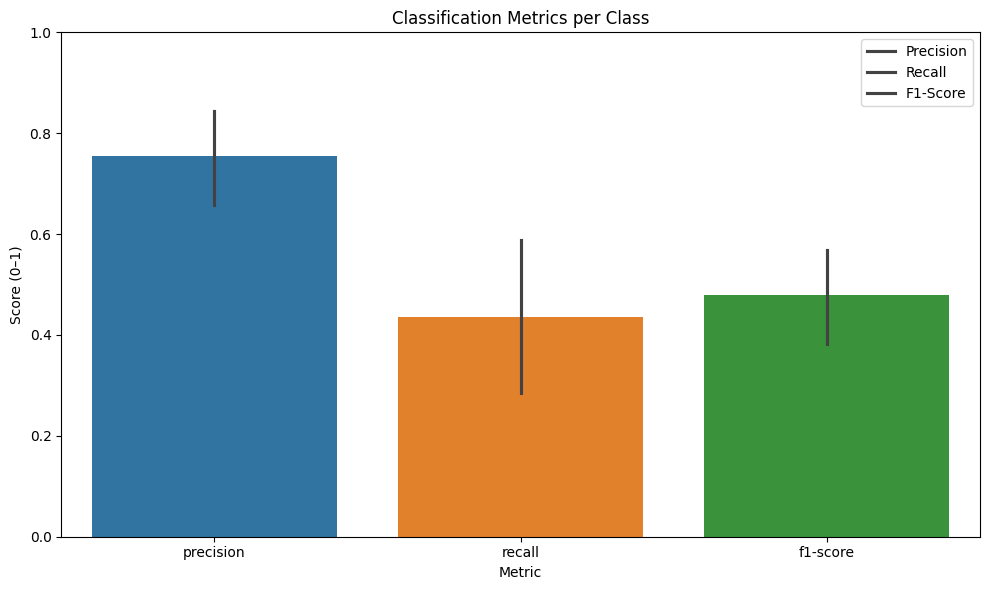


🧩 Confusion Matrix:
[[ 789    2    0    0    0    0    0   25    0    0  410]
 [   9  770    1   60    4    0    1    0    0   24  347]
 [  19   61   33   11    1   10   27    0    0    2  230]
 [  27  127    0  319    1    2    2    8    1    0  310]
 [  19  141    1   20  419    0    1   56    0    0  135]
 [ 171    3    0    0    0  142    3   56    0    0   26]
 [  11   62    4    7    3    1  198    1    0    2  514]
 [ 206    3    1    1   13    4    6  437    0    0  113]
 [ 127    2    0    1    7    2    0  127   63    0   69]
 [   1    1    0    0    0    0    0    0    0  156  656]
 [  11   11    1    1    2    0    3    0    0    6 2340]]


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("dataset/predict_country_groups_encoded.csv")


df = df.dropna(subset=["country_group"])


X = df.drop(columns=["country_group"], errors='ignore')
leakage_cols = [col for col in X.columns if "cleanliness_base" in col.lower() or "staff_base" in col.lower() or "facilities_base" in col.lower() or "value_for_money_base" in col.lower()]
X = X.drop(columns=leakage_cols)

X["location_base"] = X["score_location"] / (X["location_base"] + 1e-6)
X["comfort_base"] = X["score_comfort"] / (X["comfort_base"] + 1e-6)
y = df["country_group"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)





from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)


importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()


class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()
print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


3 Base Features


                              feature  importance
9                       location_base    0.155122
4                      score_location    0.136192
8                        comfort_base    0.117787
10                         staff_base    0.114239
0                       score_overall    0.085315
2                       score_comfort    0.082084
5                         score_staff    0.080795
3                    score_facilities    0.064663
6               score_value_for_money    0.055486
1                   score_cleanliness    0.041379
16              traveller_type_Family    0.010640
15              traveller_type_Couple    0.008992
7                         user_gender    0.006327
17                traveller_type_Solo    0.005649
11                    age_group_25-34    0.005301
12                    age_group_35-44    0.004968
13                    age_group_45-54    0.003028
41         user_country_United States    0.002629
14                      age_group_55+    0.002229


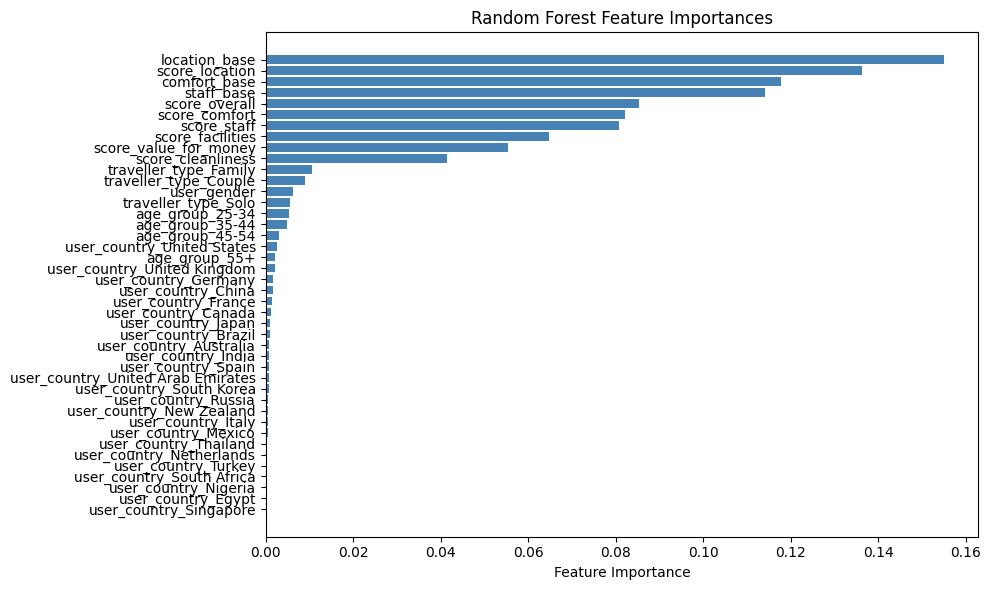

🎯 Training Accuracy: 0.7145
✅ Accuracy: 0.6075

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66      1226
           1       0.70      0.65      0.67      1216
           2       0.80      0.08      0.15       394
           3       0.86      0.45      0.59       797
           4       0.97      0.69      0.81       792
           5       0.94      0.38      0.54       401
           6       0.87      0.27      0.41       803
           7       0.64      0.78      0.71       784
           8       0.98      0.11      0.19       398
           9       0.85      0.19      0.32       814
          10       0.47      0.99      0.64      2375

    accuracy                           0.61     10000
   macro avg       0.79      0.48      0.52     10000
weighted avg       0.72      0.61      0.57     10000



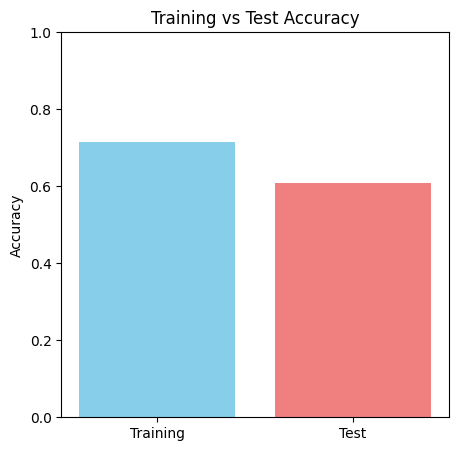

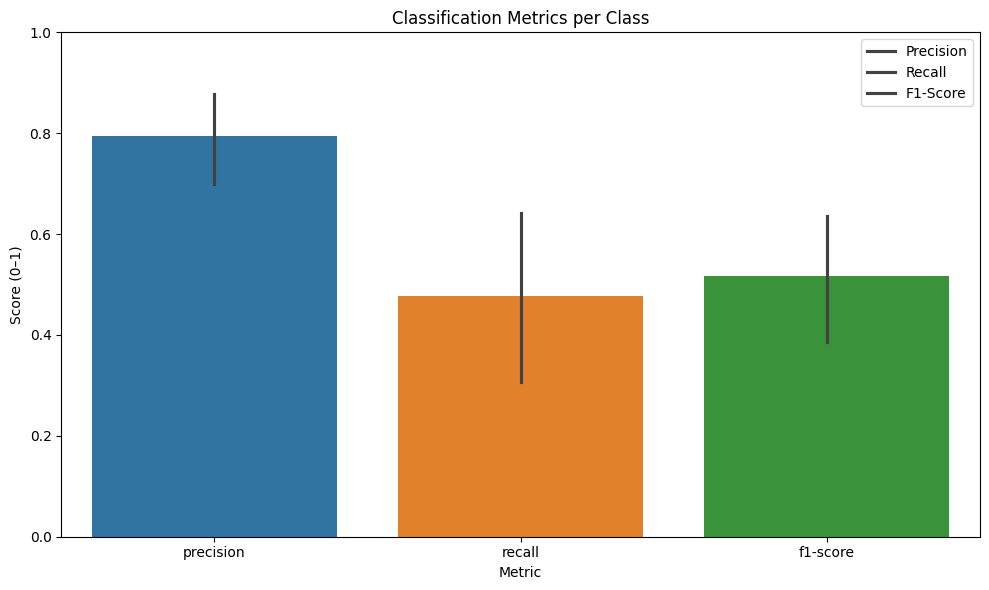


🧩 Confusion Matrix:
[[ 807    0    0    0    0    0    0   19    0    0  400]
 [   1  790    0   45    1    0    0    0    0   19  360]
 [   4   38   32    3    0    1   29    1    0    1  285]
 [  12  123    0  355    0    1    1   18    1    0  286]
 [  27  148    1   10  548    0    0   17    0    0   41]
 [ 208    0    0    0    0  151    0   36    0    0    6]
 [   1   27    6    1    5    0  219    1    0    1  542]
 [ 103    1    1    0    5    4    3  613    0    0   54]
 [  67    0    0    0    3    3    0  248   42    0   35]
 [   0    0    0    0    0    0    0    0    0  158  656]
 [   0    6    0    1    1    0    1    0    0    6 2360]]


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("dataset/predict_country_groups_encoded.csv")

df = df.dropna(subset=["country_group"])


X = df.drop(columns=["country_group"], errors='ignore')
leakage_cols = [col for col in X.columns if "cleanliness_base" in col.lower() or "facilities_base" in col.lower() or "value_for_money_base" in col.lower()]
X = X.drop(columns=leakage_cols)

X["location_base"] = X["score_location"] / (X["location_base"] + 1e-6)
X["comfort_base"] = X["score_comfort"] / (X["comfort_base"] + 1e-6)
X["staff_base"] = X["score_staff"] / (X["staff_base"] + 1e-6)
y = df["country_group"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)



from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)


importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()


class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()
print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Dropped age and country

                  feature  importance
9           location_base    0.187943
4          score_location    0.140276
10             staff_base    0.129841
8            comfort_base    0.126494
2           score_comfort    0.085843
5             score_staff    0.084113
0           score_overall    0.068344
3        score_facilities    0.058194
6   score_value_for_money    0.054382
1       score_cleanliness    0.036790
12  traveller_type_Family    0.009128
11  traveller_type_Couple    0.007575
7             user_gender    0.006143
13    traveller_type_Solo    0.004935


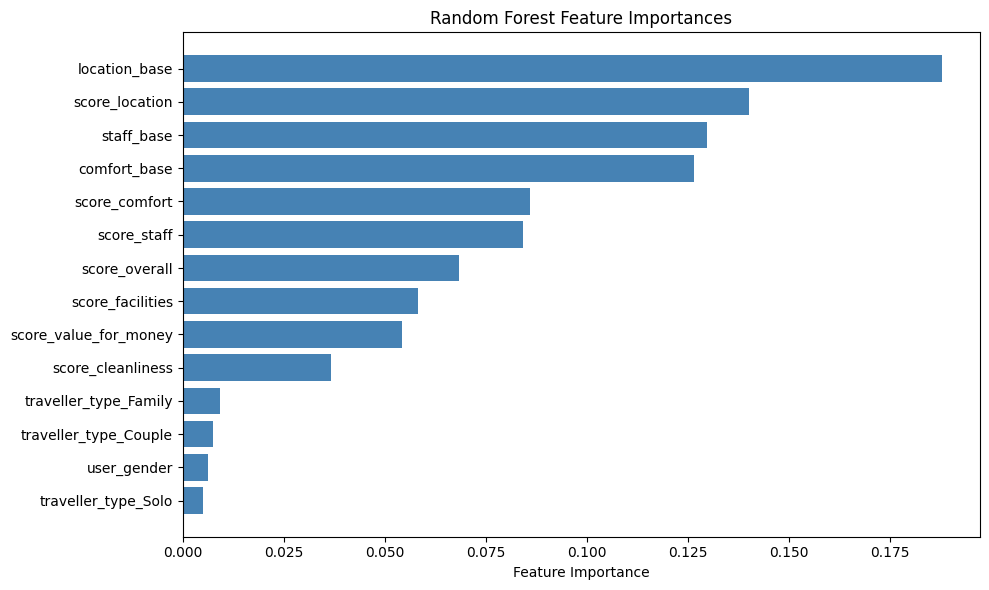

🎯 Training Accuracy: 0.8421
✅ Accuracy: 0.7432

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.69      0.77      1226
           1       0.87      0.70      0.78      1216
           2       0.72      0.44      0.55       394
           3       0.91      0.72      0.81       797
           4       0.98      0.93      0.96       792
           5       0.95      0.74      0.83       401
           6       0.83      0.58      0.68       803
           7       0.75      0.91      0.82       784
           8       0.96      0.46      0.62       398
           9       0.89      0.27      0.41       814
          10       0.57      0.99      0.72      2375

    accuracy                           0.74     10000
   macro avg       0.84      0.68      0.72     10000
weighted avg       0.80      0.74      0.73     10000



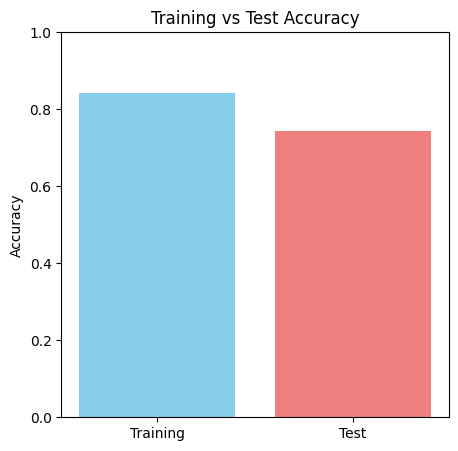

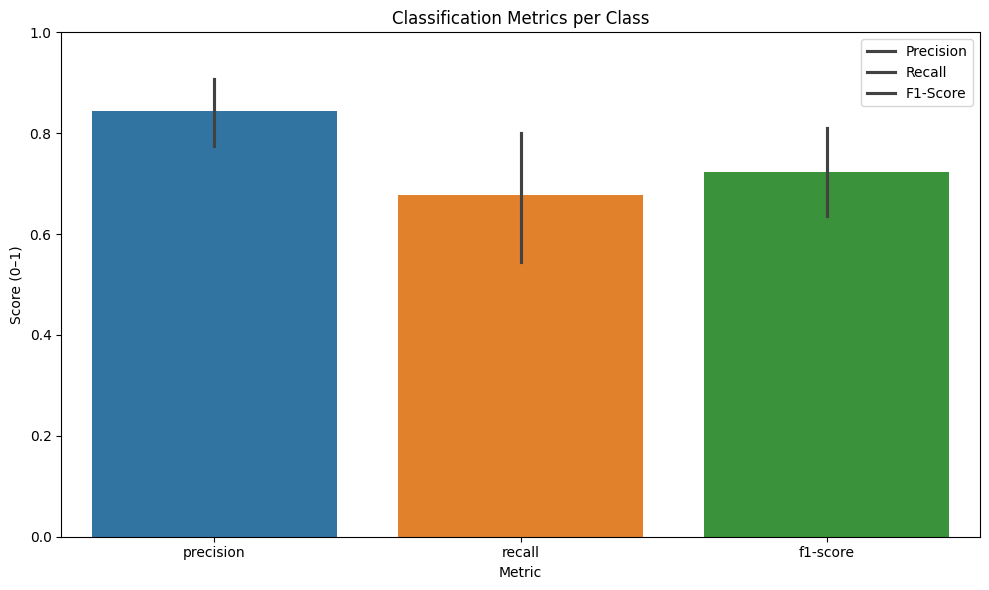


🧩 Confusion Matrix:
[[ 848    0    0    0    0    1    0   14    1    2  360]
 [   0  857    2   50    1    0    2    0    0   15  289]
 [   0    9  174    0    1    3   81    0    0    1  125]
 [   2   75    0  576    0    2    3    8    1    0  130]
 [   5   33    1    1  740    0    0   10    0    0    2]
 [  75    0    0    0    0  297    2   27    0    0    0]
 [   0   10   62    2    3    0  464    2    0    2  258]
 [  36    1    1    0    9    8    2  717    5    0    5]
 [  21    0    0    1    3    3    0  179  183    0    8]
 [   0    0    0    0    0    0    0    0    0  218  596]
 [   0    1    3    0    0    0    6    0    0    7 2358]]


In [12]:
low_importance_features = importance_df[importance_df["importance"] < 0.0056]["feature"]
X = X.drop(columns=low_importance_features)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()


class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()
print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Use all base all scores all categorical

                              feature  importance
11                      location_base    0.115890
4                      score_location    0.104779
10                    facilities_base    0.096446
9                        comfort_base    0.082257
12                         staff_base    0.082102
3                    score_facilities    0.072765
0                       score_overall    0.069336
8                    cleanliness_base    0.060661
2                       score_comfort    0.060130
5                         score_staff    0.059852
13               value_for_money_base    0.059470
6               score_value_for_money    0.057088
1                   score_cleanliness    0.040631
19              traveller_type_Family    0.004932
18              traveller_type_Couple    0.004854
7                         user_gender    0.004046
14                    age_group_25-34    0.003372
15                    age_group_35-44    0.003293
20                traveller_type_Solo    0.003277


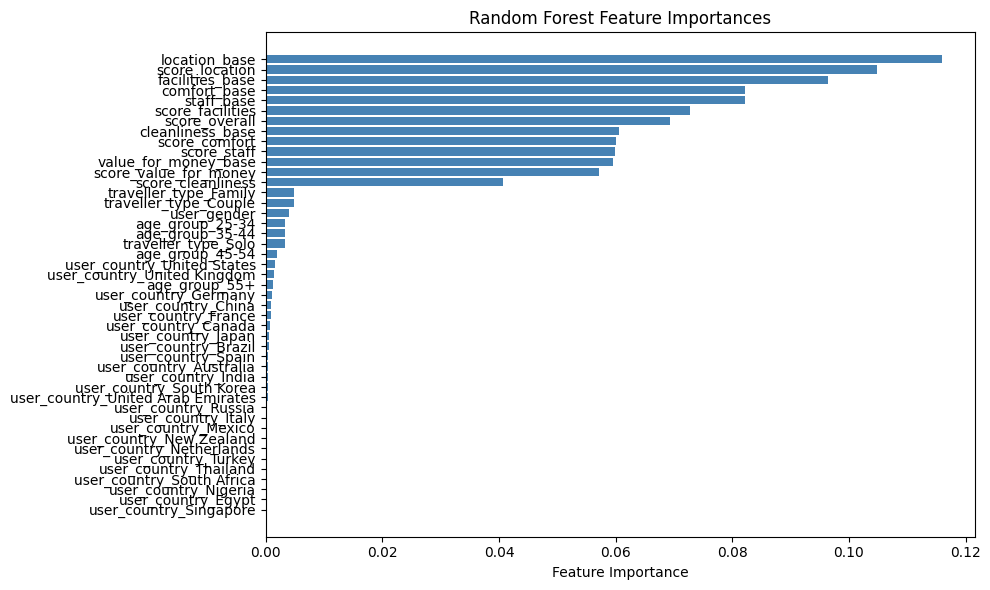

🎯 Training Accuracy: 0.8047


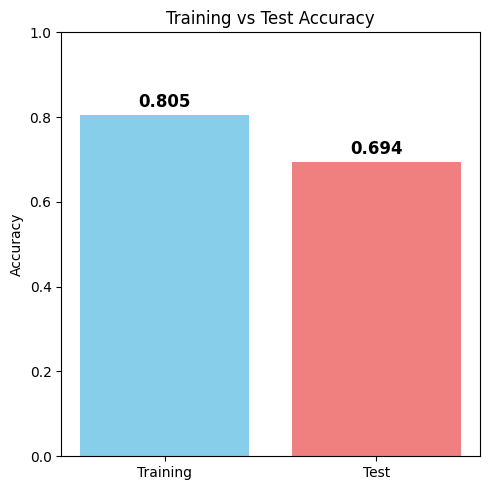

✅ Accuracy: 0.6937

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70      1226
           1       0.85      0.76      0.80      1216
           2       1.00      0.16      0.28       394
           3       0.99      0.58      0.73       797
           4       1.00      0.83      0.91       792
           5       0.99      0.40      0.57       401
           6       0.97      0.45      0.62       803
           7       0.67      0.92      0.78       784
           8       0.96      0.07      0.13       398
           9       0.99      0.44      0.61       814
          10       0.52      1.00      0.68      2375

    accuracy                           0.69     10000
   macro avg       0.88      0.57      0.62     10000
weighted avg       0.80      0.69      0.67     10000



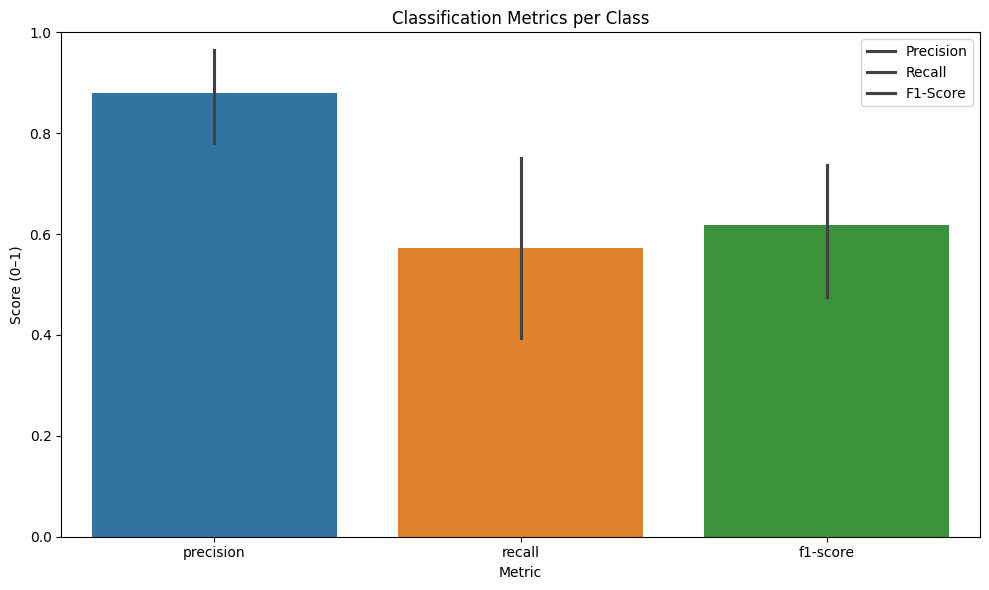


🧩 Confusion Matrix:
[[ 826    0    0    0    0    0    0    3    0    0  397]
 [   0  920    0    4    0    0    0    0    0    1  291]
 [   0    4   65    0    0    0   12    0    0    0  313]
 [   1   21    0  459    0    0    1   28    0    0  287]
 [   5   99    0    0  659    0    0    1    0    0   28]
 [ 236    0    0    0    0  161    0    4    0    0    0]
 [   3   33    0    0    1    0  365    2    0    1  398]
 [  45    0    0    0    0    0    0  725    1    0   13]
 [  30    0    0    0    0    1    0  316   27    0   24]
 [   0    1    0    0    0    0    0    0    0  355  458]
 [   0    0    0    0    0    0    0    0    0    0 2375]]


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("dataset/predict_country_groups_encoded.csv")


df = df.dropna(subset=["country_group"])


X = df.drop(columns=["country_group"], errors='ignore')


X["location_base"] = X["score_location"] / (X["location_base"] + 1e-6)
X["comfort_base"] = X["score_comfort"] / (X["comfort_base"] + 1e-6)
X["staff_base"] = X["score_staff"] / (X["staff_base"] + 1e-6)
X["cleanliness_base"] = X["score_cleanliness"] / (X["cleanliness_base"] + 1e-6)
X["facilities_base"] = X["score_facilities"] / (X["facilities_base"] + 1e-6)
X["value_for_money_base"] = X["score_value_for_money"] / (X["value_for_money_base"] + 1e-6)
y = df["country_group"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)



from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)


importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, acc in enumerate([train_acc, test_acc]):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()


class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Score and Base only


                  feature  importance
10          location_base    0.150145
4          score_location    0.108561
9         facilities_base    0.108371
8            comfort_base    0.085983
11             staff_base    0.085005
3        score_facilities    0.072832
12   value_for_money_base    0.065660
2           score_comfort    0.060427
6   score_value_for_money    0.059262
7        cleanliness_base    0.058368
0           score_overall    0.054284
5             score_staff    0.054007
1       score_cleanliness    0.037094


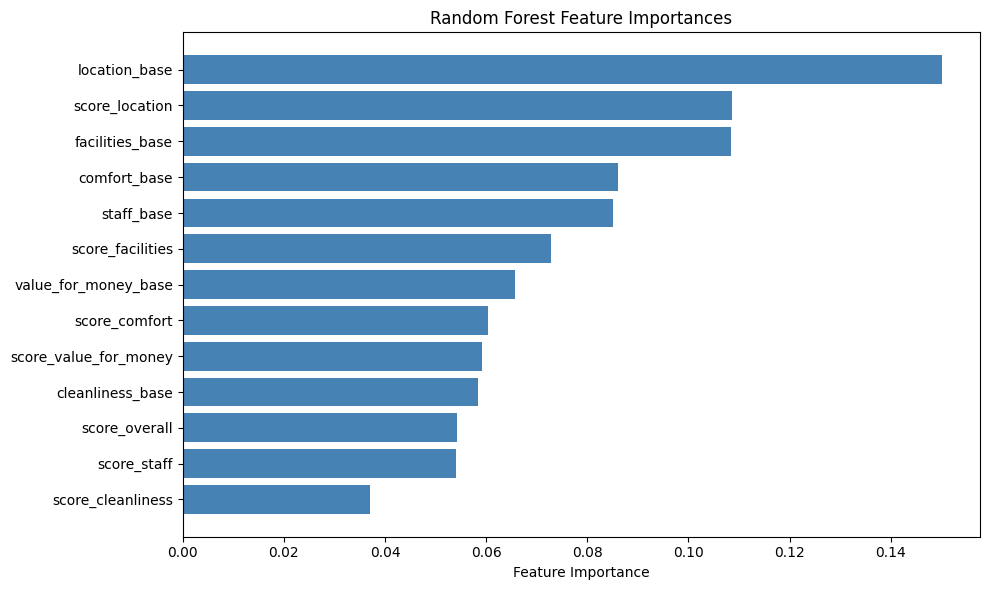

🎯 Training Accuracy: 0.9459
✅ Accuracy: 0.872

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1226
           1       0.98      0.88      0.93      1216
           2       0.92      0.75      0.83       394
           3       1.00      0.90      0.95       797
           4       1.00      0.99      0.99       792
           5       1.00      0.86      0.92       401
           6       0.98      0.88      0.93       803
           7       0.77      0.98      0.86       784
           8       0.98      0.42      0.59       398
           9       1.00      0.75      0.86       814
          10       0.72      1.00      0.84      2375

    accuracy                           0.87     10000
   macro avg       0.93      0.83      0.86     10000
weighted avg       0.90      0.87      0.87     10000



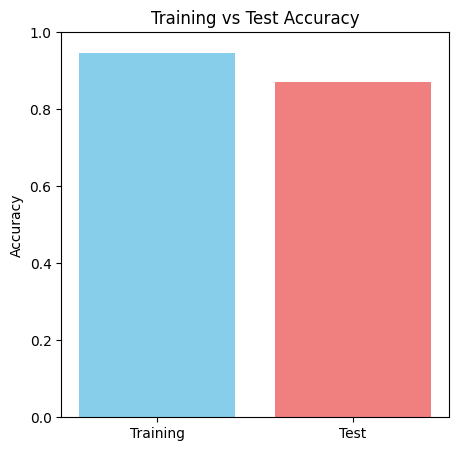

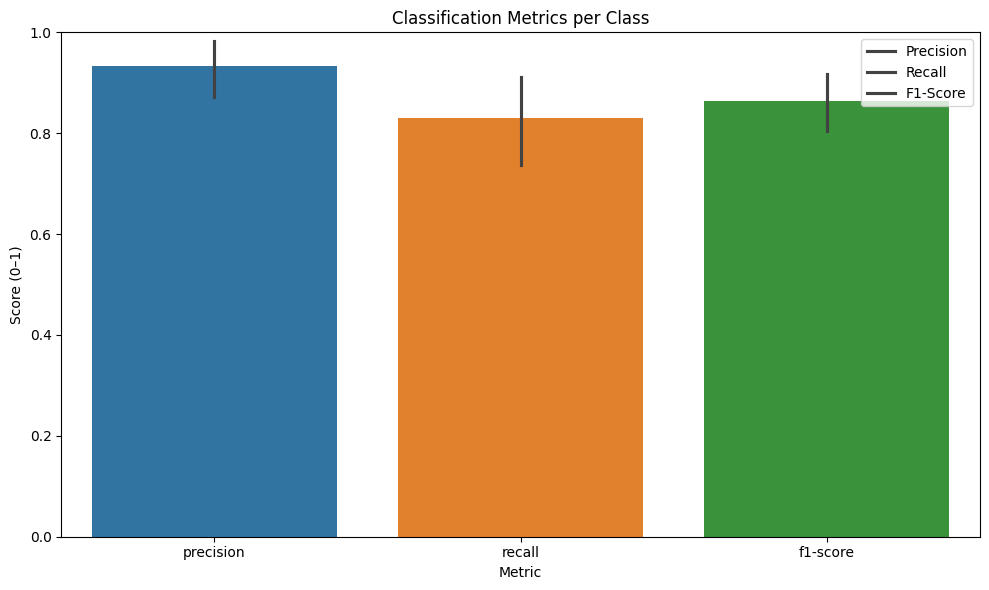


🧩 Confusion Matrix:
[[ 883    0    0    0    0    0    0    2    0    0  341]
 [   0 1066    0    3    0    0    1    0    0    1  145]
 [   0    1  295    0    0    0   13    0    0    0   85]
 [   0    5    0  718    0    0    0    6    0    0   68]
 [   0    7    1    0  784    0    0    0    0    0    0]
 [  56    0    0    0    0  343    0    2    0    0    0]
 [   1    4   21    0    1    0  709    0    0    1   66]
 [   7    0    0    0    0    0    0  771    4    0    2]
 [   6    0    0    0    0    0    0  222  168    0    2]
 [   0    0    0    0    0    0    0    0    0  613  201]
 [   0    0    3    0    0    0    2    0    0    0 2370]]


In [14]:
low_importance_features = importance_df[importance_df["importance"] < 0.04]["feature"]
X = X.drop(columns=low_importance_features)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()


class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()


print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Final Model All score all base user gender, Age range and traveller type

                  feature  importance
11          location_base    0.138419
4          score_location    0.104147
10        facilities_base    0.102804
12             staff_base    0.085474
9            comfort_base    0.081356
3        score_facilities    0.076195
13   value_for_money_base    0.063697
0           score_overall    0.059888
6   score_value_for_money    0.059364
8        cleanliness_base    0.058067
2           score_comfort    0.056980
5             score_staff    0.056061
1       score_cleanliness    0.036600
19  traveller_type_Family    0.003808
18  traveller_type_Couple    0.003751
7             user_gender    0.003432
14        age_group_25-34    0.002798
15        age_group_35-44    0.002608
20    traveller_type_Solo    0.002454
16        age_group_45-54    0.001344
17          age_group_55+    0.000754


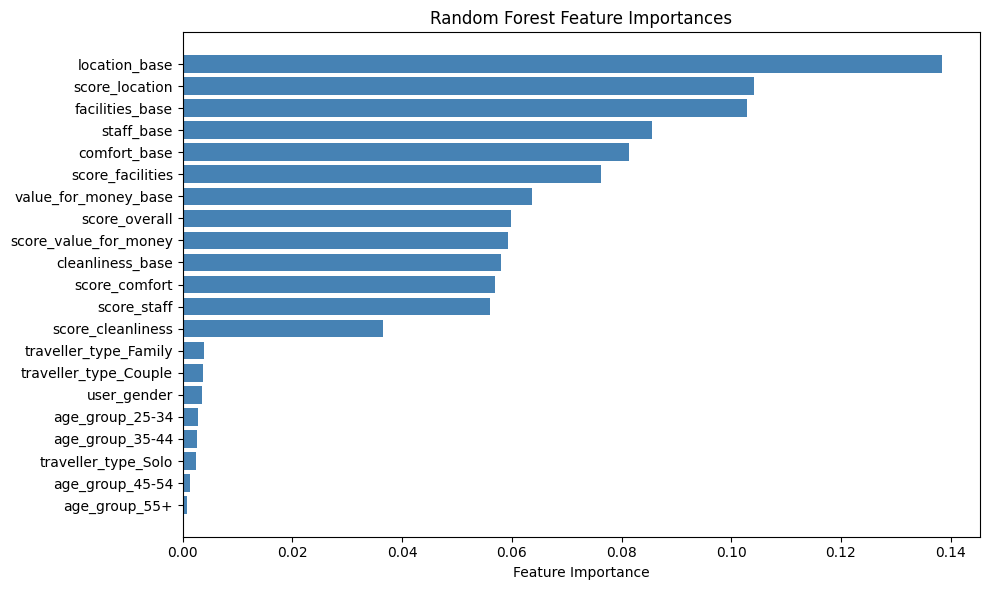

🎯 Training Accuracy: 0.9142


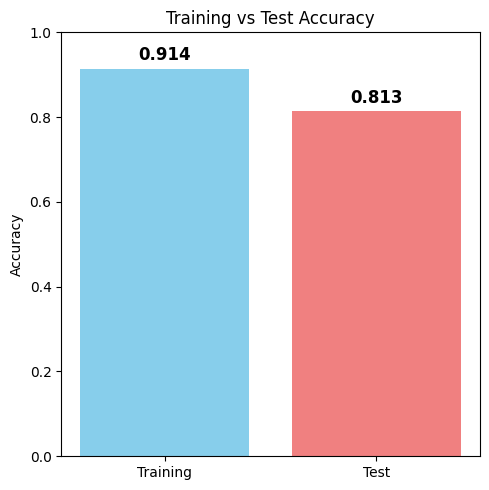

✅ Accuracy: 0.8134

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      1226
           1       0.95      0.83      0.89      1216
           2       0.93      0.52      0.66       394
           3       1.00      0.77      0.87       797
           4       0.99      0.96      0.98       792
           5       1.00      0.73      0.84       401
           6       0.98      0.79      0.87       803
           7       0.72      0.97      0.83       784
           8       0.97      0.29      0.44       398
           9       1.00      0.64      0.78       814
          10       0.64      1.00      0.78      2375

    accuracy                           0.81     10000
   macro avg       0.91      0.74      0.79     10000
weighted avg       0.86      0.81      0.81     10000



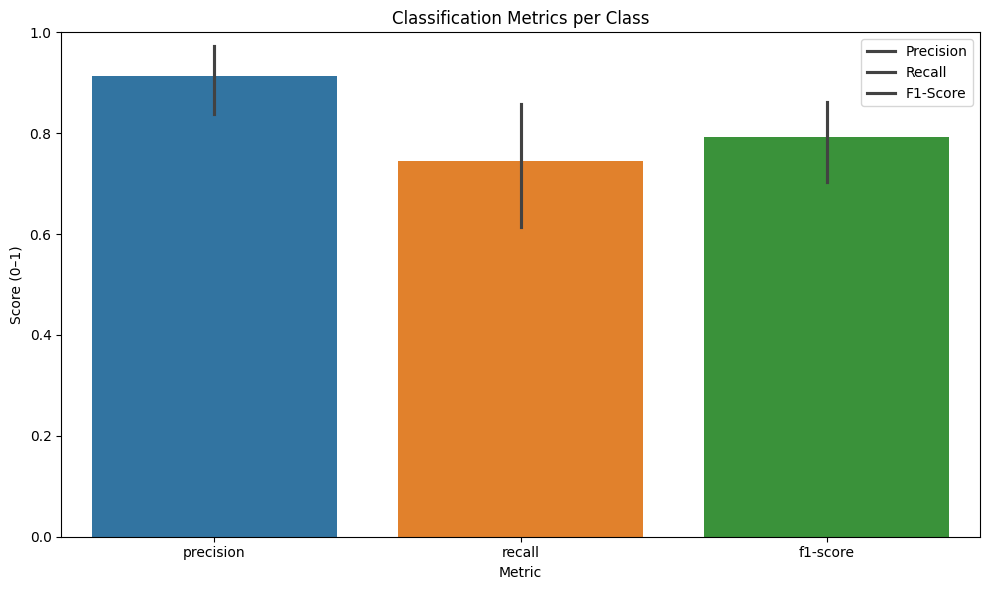


🧩 Confusion Matrix:
[[ 846    0    0    0    0    0    0    2    0    0  378]
 [   0 1013    0    2    0    0    0    0    0    0  201]
 [   0    2  204    0    0    0   12    0    0    0  176]
 [   0    7    0  612    0    0    1   19    1    0  157]
 [   0   25    0    0  761    0    0    0    0    0    6]
 [ 104    0    0    0    0  293    0    4    0    0    0]
 [   2   15   13    0    5    0  632    1    0    0  135]
 [  15    0    0    0    0    0    0  762    3    0    4]
 [   7    0    0    0    0    0    0  270  115    0    6]
 [   0    0    0    0    0    0    0    0    0  524  290]
 [   0    0    3    0    0    0    0    0    0    0 2372]]


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("dataset/predict_country_groups_encoded.csv")


df = df.dropna(subset=["country_group"])


X = df.drop(columns=["country_group"], errors='ignore')

X = X.loc[:, ~X.columns.str.startswith("user_country_")]


X["location_base"] = X["score_location"] / (X["location_base"] + 1e-6)
X["comfort_base"] = X["score_comfort"] / (X["comfort_base"] + 1e-6)
X["staff_base"] = X["score_staff"] / (X["staff_base"] + 1e-6)
X["cleanliness_base"] = X["score_cleanliness"] / (X["cleanliness_base"] + 1e-6)
X["facilities_base"] = X["score_facilities"] / (X["facilities_base"] + 1e-6)
X["value_for_money_base"] = X["score_value_for_money"] / (X["value_for_money_base"] + 1e-6)
y = df["country_group"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)



from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)


importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"🎯 Training Accuracy: {train_acc:.4f}")
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.bar(["Training", "Test"], [train_acc, test_acc], color=["skyblue", "lightcoral"])
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, acc in enumerate([train_acc, test_acc]):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()


class_report_df = report_df.iloc[:-3, :]


plt.figure(figsize=(10, 6))
sns.barplot(data=class_report_df[['precision', 'recall', 'f1-score']])
plt.title("Classification Metrics per Class")
plt.xlabel("Metric")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.legend(labels=['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.show()

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [16]:
import shap
import numpy as np
import pandas as pd


X_train = pd.DataFrame(X_train, columns=X.columns)
X_test  = pd.DataFrame(X_test, columns=X.columns)


background = shap.sample(X_train, 100, random_state=42)
X_test_sample = shap.sample(X_test, 300, random_state=42)


In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)
print("✅ SHAP values shape:", np.array(shap_values).shape)


✅ SHAP values shape: (300, 21, 11)


In [18]:
print("Type of shap_values:", type(shap_values))
if isinstance(shap_values, list):
    for i, arr in enumerate(shap_values):
        print(f"Class {i}: {arr.shape}")
else:
    print("shap_values shape:", shap_values.shape)

print("X_test_sample shape:", X_test_sample.shape)

Type of shap_values: <class 'numpy.ndarray'>
shap_values shape: (300, 21, 11)
X_test_sample shape: (300, 21)


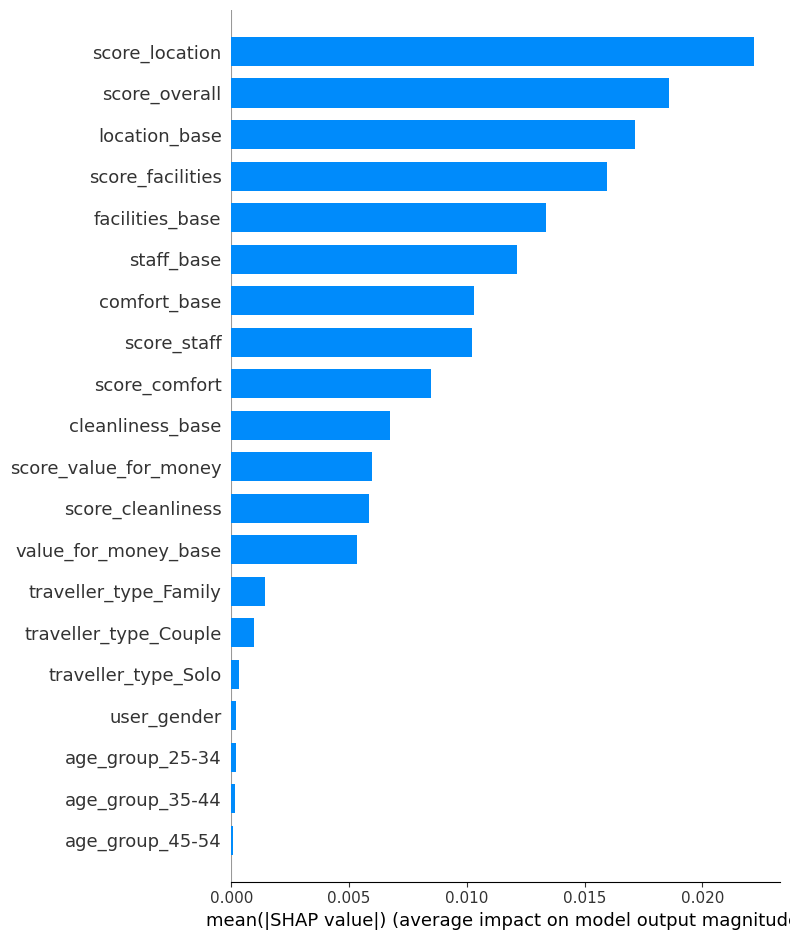

In [19]:
import numpy as np


shap_values_mean = np.mean(np.abs(shap_values), axis=2)

shap.summary_plot(
    shap_values_mean,
    X_test_sample,
    feature_names=X_train.columns,
    plot_type="bar"
)

In [20]:
i = 211
pred_class = model.predict(X_test_sample.iloc[[i]])[0]
class_ix = pred_class


shap.initjs()
shap.force_plot(
    explainer.expected_value[class_ix],
    shap_values[i, :, class_ix],
    X_test_sample.iloc[i],
    feature_names=X_train.columns
)

In [21]:
print(df.groupby("country_group")[["score_overall","score_location","score_staff"]].mean())


                      score_overall  score_location  score_staff
country_group                                                   
Africa                     8.808871        9.090753     8.844814
East_Asia                  9.012808        8.990497     9.149770
Eastern_Europe             8.966954        8.994772     9.034619
Middle_East                9.004996        9.061235     9.070675
North_America              8.934553        9.094725     8.888718
North_America_Mexico       8.759381        8.991866     8.763323
Oceania                    8.960289        9.261360     8.957275
South_America              8.845840        9.162864     8.822563
South_Asia                 8.841227        9.130970     8.817798
Southeast_Asia             9.029828        9.366118     9.040197
Western_Europe             9.000977        9.361351     9.023198


In [22]:
# @title
%pip install lime


In [23]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd


In [24]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test  = pd.DataFrame(X_test, columns=X.columns)


In [25]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=le.classes_.tolist(),
    discretize_continuous=True,
    mode='classification'
)


In [26]:
j = 2

exp = explainer_lime.explain_instance(
    X_test.iloc[j].values,
    model.predict_proba,
    num_features=10,
    top_labels=len(le.classes_)
)


exp.show_in_notebook(show_table=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
